In [9]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [10]:
df = pd.read_csv('data/stud.csv')

In [11]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [12]:
X = df.drop(columns=['math_score'],axis=1)

In [13]:
X

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [14]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [15]:
y = df['math_score']
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [16]:
num_features =  X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(), cat_features)
    ]
)

In [17]:
X = preprocessor.fit_transform(X)

In [18]:
X.shape

(1000, 19)

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
X_test.shape, X_train.shape

((200, 19), (800, 19))

In [26]:
def evaluate_model(X_test_or_test, y_pred):
    r2 = r2_score(X_test_or_test, y_pred)
    mae = mean_absolute_error(X_test_or_test, y_pred)
    mse = mean_squared_error(X_test_or_test, y_pred)
    print(f"R^2 Score: {r2:.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"Mean Squared Error: {mse:.4f}")

In [24]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "KNN Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "AdaBoost Regressor": AdaBoostRegressor(random_state=42),
    "Support Vector Regressor": SVR(),
    "XGBoost Regressor": XGBRegressor(random_state=42),
    "CatBoost Regressor": CatBoostRegressor(random_state=42, verbose=0)
}

In [31]:
model_list = []
r2_list = []

for k,v in models.items():
    model = v
    model.fit(X_train, y_train)
    print(f"Model: {k}")
    print('Model performance for Training set')
    evaluate_model(y_train, model.predict(X_train))
    
    print('-' * 30)
    
    print('Model performance for Testing set')
    evaluate_model(y_test, model.predict(X_test))
    
    model_list.append(k)
    r2_list.append(r2_score(y_test, model.predict(X_test)))
    print('=' * 30)
    print('\n')

Model: Linear Regression
Model performance for Training set
R^2 Score: 0.8743
Mean Absolute Error: 4.2667
Mean Squared Error: 28.3349
------------------------------
Model performance for Testing set
R^2 Score: 0.8804
Mean Absolute Error: 4.2148
Mean Squared Error: 29.0952


Model: Ridge Regression
Model performance for Training set
R^2 Score: 0.8743
Mean Absolute Error: 4.2650
Mean Squared Error: 28.3378
------------------------------
Model performance for Testing set
R^2 Score: 0.8806
Mean Absolute Error: 4.2111
Mean Squared Error: 29.0563


Model: Lasso Regression
Model performance for Training set
R^2 Score: 0.8071
Mean Absolute Error: 5.2063
Mean Squared Error: 43.4783
------------------------------
Model performance for Testing set
R^2 Score: 0.8253
Mean Absolute Error: 5.1579
Mean Squared Error: 42.5063


Model: KNN Regressor
Model performance for Training set
R^2 Score: 0.8552
Mean Absolute Error: 4.5168
Mean Squared Error: 32.6355
------------------------------
Model performanc

In [32]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
1,Ridge Regression,0.880593
0,Linear Regression,0.880433
5,Random Forest Regressor,0.850403
6,AdaBoost Regressor,0.850225
9,CatBoost Regressor,0.850185
2,Lasso Regression,0.825320
8,XGBoost Regressor,0.821220
3,KNN Regressor,0.783770
4,Decision Tree Regressor,0.748252
7,Support Vector Regressor,0.728600


Text(0, 0.5, 'Predicted')

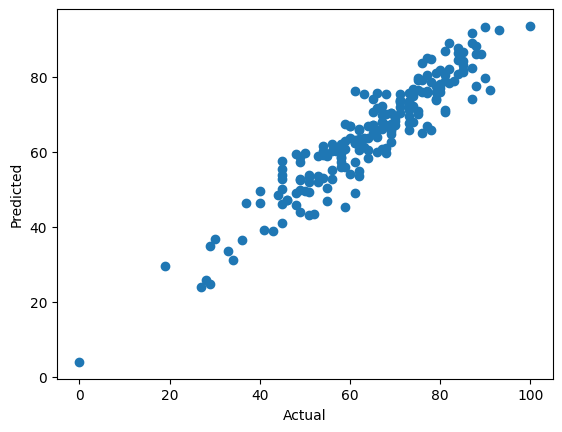

In [38]:
best_model = Ridge()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

<Axes: xlabel='math_score'>

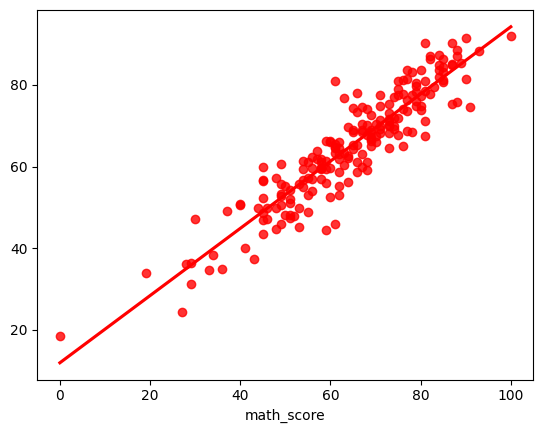

In [35]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red')

In [36]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,74.686700,16.313300
737,53,55.602397,-2.602397
740,80,77.294819,2.705181
660,74,77.079776,-3.079776
411,84,87.312492,-3.312492
...,...,...,...
408,52,47.918169,4.081831
332,62,58.538144,3.461856
208,74,69.307462,4.692538
613,65,68.494894,-3.494894
